In [29]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
from torch.utils import data

In [19]:
def use_svg_display():  #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

def plot(X, Y, xlabel=None, ylabel=None, legend=[], xlim=None,ylim=None, xscale='linear', yscale='linear', fmts=None,figsize=(3.5, 2.5), axes=None):
    """绘制多条曲线"""
    set_figsize(figsize)
    axes = axes if axes else plt.gca()
    if not isinstance(Y, list):
        Y = [Y]
    if fmts is None:
        fmts = ['-'] * len(Y)
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x.numpy(), y.numpy(), fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

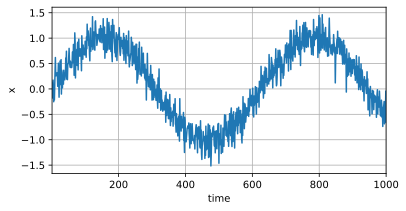

In [20]:
T = 1000 #总共产生1000个点
time = torch.arange(1,T+1,dtype=torch.float32)
x = torch.sin(0.01*time)+torch.normal(0,0.2,(T,))
plot([time],[x],'time','x',xlim=[1,1000],figsize=(6,3))

In [26]:
tau = 4
features = torch.zeros((T-tau,tau))
for i in range(tau):
    features[:,i] = x[i:T-tau+i]
labels = x[tau:].reshape((-1,1))

In [30]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    dataset = data.TensorDataset(*data_arrays) # 将输入数据封装为 TensorDataset
    return data.DataLoader(dataset, batch_size, shuffle=is_train) # 返回 DataLoader

batch_size,n_train = 16,600
# 只有前n_train个样本用于训练
train_iter = load_array((features[:n_train],labels[:n_train]),batch_size,is_train=True)

In [31]:
# 初始化网络权重的函数
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4,10),
                        nn.ReLU(),
                        nn.Linear(10,1))
    net.apply(init_weights)
    return net

# 平方损失注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')

In [36]:
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

def evaluate_loss(net, data_iter, loss): #@save
    """评估给定数据集上模型的损失"""
    metric = Accumulator(2) # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [37]:
def train(net,train_iter,loss,epochs,lr):
    trainer = torch.optim.Adam(net.parameters(),lr)
    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()
            l = loss(net(X),y)
            l.sum().backward()
            trainer.step()
        print(f'epoch{epoch+1},'f'loss:{evaluate_loss(net,train_iter,loss):f}')

net = get_net()
train(net,train_iter,loss,5,0.01)

epoch1,loss:0.062412
epoch2,loss:0.054280
epoch3,loss:0.052551
epoch4,loss:0.051362
epoch5,loss:0.049445


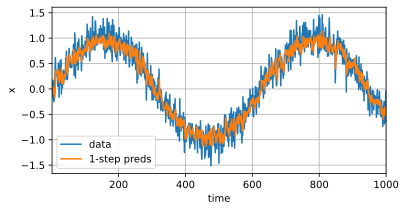

In [44]:
onestep_preds = net(features)
plot([time,time[tau:]],[x.detach(),onestep_preds.detach()],'time','x',legend=['data','1-step preds'],xlim=[1,1000],figsize=(6,3))

In [46]:
multistep_preds = torch.zeros(T)
multistep_preds[:n_train+tau] = x[:n_train+tau]
for i in range(n_train+tau,T):
    multistep_preds[i] = net(multistep_preds[i-tau:i].reshape((1,-1)))

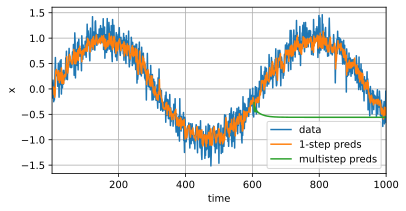

In [50]:
plot([time,time[tau:],time[n_train+tau:]],[x.detach(),onestep_preds.detach(),multistep_preds[n_train+tau:].detach()],'time','x',legend=['data','1-step preds','multistep preds'],xlim=[1,1000],figsize=(6,3))

In [51]:
max_steps = 64
features = torch.zeros((T-tau-max_steps+1,tau+max_steps))
# 列i(i<tau)是来自x的观测，其时间步从(i+1)到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:,i] = x[i:i+T-tau-max_steps+1]
#列i(i>=tau)是来自(i-tau+1)步的预测，其时间步从(i+1)到(i+T-tau-max_steps+1)
for i in range(tau,tau+max_steps):
    features[:,i] = net(features[:,i-tau:i]).reshape(-1)

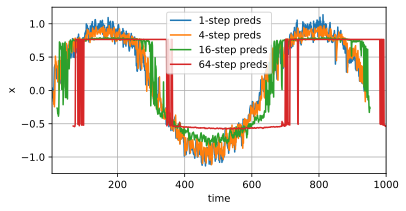

In [54]:
steps = (1,4,16,64)
plot([time[tau+i-1:T-max_steps+i] for i in steps],[features[:,(tau+i-1)].detach() for i in steps],'time','x',legend=[f'{i}-step preds' for i in steps],xlim=[5,1000],figsize=(6,3))